# NovaCred Data Governance & Privacy Audit
**Role:** Governance Officer

Welcome to the NovaCred Data Governance Audit! Our team is acting as the Data Governance Task Force for NovaCred, a fintech startup that uses machine learning to make credit decisions. 

Because our algorithm determines who gets access to financial resources, it is classified as a **High-Risk AI System** under the EU AI Act. Before our engineers can build a predictive model, we must legally prove that our historical training data is safe, fair, and compliant.

### Personally Identifiable Information (PII) Taxonomy
To comply with GDPR, we must first understand what personal data we hold. We have audited the `raw_credit_applications.json` schema and classified the fields based on their privacy risk:

| Classification | Fields | Privacy Risk & Definition |
| :--- | :--- | :--- |
| **Direct Identifiers** | `full_name`, `email`, `ssn`, `ip_address` | These fields point directly to a specific individual. The `ssn` is highly sensitive as it is a permanent national identifier.`ip_address` can track an applicant's exact device and location[cite: 45]. |
| **Indirect (Quasi) Identifiers** | `date_of_birth`, `gender`, `zip_code` | Harmless on their own, but when combined, they can uniquely identify a person. |
| **Behavioral Data** | `spending_behavior` | Highly personal data detailing monthly spending amounts across categories[cite: 45]. Depending on the categories, this can reveal sensitive lifestyle or health information. |
| **Financial / Profiling Data** | `annual_income`, `debt_to_income`, `loan_approved` | Not PII on their own, but become highly sensitive profiling data once linked to an individual. |

**Audit Objectives:**
1. **Data Quality:** Identify missing, inconsistent, or invalid data and remediate it.
2. **Privacy by Design:** Pseudonymize direct identifiers and minimize indirect identifiers.
3. **Algorithmic Fairness:** Test for historical discrimination, proxy bias, and interaction effects.

In [15]:
import pandas as pd
import numpy as np
import json
import hashlib
import hmac
import secrets
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for our fairness charts later
sns.set_theme(style="whitegrid")

# Load the data and flatten the nested JSON so it's easier to work with
file_path = '../data/raw_credit_applications.json' 
with open(file_path, 'r') as file:
    raw_json = json.load(file)

df = pd.json_normalize(raw_json)
print(f"Dataset successfully loaded! We have {len(df)} credit applications to review.")

Dataset successfully loaded! We have 502 credit applications to review.


## Part 1: Automated Data Quality Audit & Remediation

In machine learning, there is a golden rule: *"Garbage In, Garbage Out."* If we train our AI on broken data, the AI will learn bad patterns and make terrible credit decisions. Furthermore, the EU AI Act (Art. 10) legally requires high-risk systems to use training data that is relevant, representative, and free of errors.

We are running an algorithmic audit to score the dataset across critical Data Quality dimensions[cite: 126]. Crucially, to meet the highest governance standards, we will **remediate** these issues in code before moving to our fairness analysis so our metrics are accurate.

In [18]:
print("--- RUNNING DATA QUALITY CHECKS ---\n")

# 1. Uniqueness
duplicate_ids = df.duplicated(subset=['_id'], keep=False).sum()
duplicate_ssns = df.duplicated(subset=['applicant_info.ssn'], keep=False).sum()
print(f"Duplicate Application IDs: {duplicate_ids}")
print(f"Duplicate SSNs across different apps: {duplicate_ssns}")

# 2. Consistency: Gender and Dates
print("\nChecking gender encodings:")
if 'applicant_info.gender' in df.columns:
    print(f" Found ways gender is typed out: {df['applicant_info.gender'].unique()}")

print("\nChecking Date of Birth formats:")
dob_formats = df['applicant_info.date_of_birth'].dropna().apply(
    lambda x: 'YYYY-MM-DD' if re.match(r'^\d{4}-\d{2}-\d{2}$', str(x)) else ('MM/DD/YYYY' if re.match(r'^\d{2}/\d{2}/\d{4}$', str(x)) else 'Other')
)
print(dob_formats.value_counts().to_string())

# 3. Validity: Impossible values
print("\nChecking for impossible financial numbers:")
incomes = pd.to_numeric(df['financials.annual_income'], errors='coerce')
string_incomes = df['financials.annual_income'].apply(lambda x: isinstance(x, str)).sum()
print(f" - Incomes saved as text strings instead of numbers: {string_incomes}")
print(f" - Applications with negative or zero income: {(incomes <= 0).sum()}")

print("\n--- REMEDIATING DATA QUALITY ISSUES (FIXING THE DATA) ---")
df_clean = df.copy()

# Fix 1: Standardize Gender
df_clean['std_gender'] = df_clean['applicant_info.gender'].replace({
    'M': 'Male', 'F': 'Female', '': 'Unknown'
}).fillna('Unknown')

# Fix 2: Cast string incomes to numbers
df_clean['financials.annual_income'] = pd.to_numeric(df_clean['financials.annual_income'], errors='coerce')

# Fix 3: Standardize Dates to datetime objects
df_clean['applicant_info.date_of_birth'] = pd.to_datetime(df_clean['applicant_info.date_of_birth'], errors='coerce')

# Fix 4: Drop Invalid Business Values (Negative income, DTI > 100%)
valid_mask = (
    (df_clean['financials.annual_income'] > 0) & 
    (pd.to_numeric(df_clean['financials.debt_to_income'], errors='coerce') <= 1.0) &
    (pd.to_numeric(df_clean['financials.credit_history_months'], errors='coerce') >= 0)
)
records_before = len(df_clean)
df_clean = df_clean[valid_mask].copy()

print(f" - Standardized gender encodings to 'Male', 'Female', and 'Unknown'.")
print(f" - Converted string incomes to numeric float values.")
print(f" - Standardized dates to proper datetime objects.")
print(f" Dropped {records_before - len(df_clean)} records with impossible financial values.")

--- RUNNING DATA QUALITY CHECKS ---

Duplicate Application IDs: 4
Duplicate SSNs across different apps: 11

Checking gender encodings:
 Found ways gender is typed out: ['Male' 'M' 'F' 'Female' '' nan]

Checking Date of Birth formats:
applicant_info.date_of_birth
YYYY-MM-DD    340
MM/DD/YYYY    101
Other          60

Checking for impossible financial numbers:
 - Incomes saved as text strings instead of numbers: 8
 - Applications with negative or zero income: 1

--- REMEDIATING DATA QUALITY ISSUES (FIXING THE DATA) ---
 - Standardized gender encodings to 'Male', 'Female', and 'Unknown'.
 - Converted string incomes to numeric float values.
 - Standardized dates to proper datetime objects.
 Dropped 9 records with impossible financial values.


## Part 2: Privacy by Design (Pseudonymization & Minimization)

### The Security Gap
Currently, our dataset stores highly sensitive identifiers like the `ssn` in plain text. A single database leak would expose permanent national IDs, resulting in catastrophic identity theft and massive GDPR fines. 

### Our Algorithmic Solution
To comply with GDPR Article 5 and 32, we are applying two advanced data governance techniques:

**1. Cryptographic Pseudonymization (HMAC-SHA256)**
We cannot simply delete the SSN, as our Data Engineers need it to track duplicates. Instead, we use an HMAC cryptographic hash. HMAC injects a secret, cryptographically generated "salt" (password) into the SSN before hashing it. Without the secret salt, it is mathematically impossible for a hacker to reverse-engineer the SSN.

**2. Data Minimization (GDPR Art. 5(1)(c))**
We must only process the data absolutely necessary for a credit decision. We will apply age binning to `date_of_birth`, subnet masking to `ip_address`, and truncation to `zip_code`.

In [19]:
# Generate a secure key for hashing (Note: In a real prod environment, this lives in a secure key vault!)
HMAC_KEY = secrets.token_bytes(32)

def secure_ssn_hash(ssn):
    """Replaces SSN with a secure cryptographic hash."""
    if pd.isna(ssn) or not isinstance(ssn, str): return ssn
    return hmac.new(HMAC_KEY, ssn.encode('utf-8'), hashlib.sha256).hexdigest()

def mask_ip_subnet(ip):
    """Removes the last part of the IP address so we can't track exact devices."""
    if pd.isna(ip) or not isinstance(ip, str): return ip
    return '.'.join(ip.split('.')[:3]) + '.XXX'

def bin_age(dob):
    """Turns specific birthdays into age brackets."""
    if pd.isna(dob): return "Unknown"
    # Assuming current year is 2026 based on project timeline
    age = 2026 - dob.year 
    if age < 25: return "18-24"
    elif age < 35: return "25-34"
    elif age < 45: return "35-44"
    elif age < 55: return "45-54"
    else: return "55+"

# Apply these privacy rules to our cleaned dataframe
if 'applicant_info.ssn' in df_clean.columns:
    df_clean['crypto_ssn'] = df_clean['applicant_info.ssn'].apply(secure_ssn_hash)

if 'applicant_info.ip_address' in df_clean.columns:
    df_clean['masked_ip'] = df_clean['applicant_info.ip_address'].apply(mask_ip_subnet)

if 'applicant_info.date_of_birth' in df_clean.columns:
    df_clean['age_bracket'] = df_clean['applicant_info.date_of_birth'].apply(bin_age)

if 'applicant_info.zip_code' in df_clean.columns:
    df_clean['regional_zip'] = df_clean['applicant_info.zip_code'].astype(str).str[:3] + "XX"

# Drop the original plain-text PII columns so they are gone for good
cols_to_drop = ['applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.date_of_birth']
df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], inplace=True)

print("Privacy transformations complete! Here is what our safe data looks like now:")
df_clean[['applicant_info.full_name', 'crypto_ssn', 'masked_ip', 'age_bracket', 'regional_zip']].head(3)

Privacy transformations complete! Here is what our safe data looks like now:


,applicant_info.full_name,crypto_ssn,masked_ip,age_bracket,regional_zip
0,Jerry Smith,7f253154a67fd0de6c8ebe3720841ff82e53b948d12d1b...,192.168.48.XXX,25-34,100XX
1,Brandon Walker,ab8d4a76832d9b5227f4c19b8e5697c19c38a6c674ad6c...,10.1.102.XXX,25-34,100XX
2,Scott Moore,ff99cc6f4301d7757bd4e6a446de267e5ada3a1a3fb1e0...,10.240.193.XXX,35-44,100XX


## Part 3: Algorithmic Fairness & Bias Testing

If human loan officers were biased in the past, our AI will ingest that bias and automate discrimination at scale. To comply with the EU AI Act's fairness requirements, we must proactively test our historical decisions.

* **Disparate Impact (DI):** The "Four-Fifths Rule." We divide the approval rate of an unprivileged group by the privileged group. If the ratio falls below **0.80**, the system is legally flagged as discriminators. We test this against Gender and Age.
* **Proxy Discrimination:** When an algorithm learns to discriminate using a seemingly harmless variable that correlates with a protected class. We will test `zip_code`.

In [21]:
print("--- RUNNING FAIRNESS & BIAS TESTS ---\n")

def check_disparate_impact(data, feature, privileged, unprivileged, target='decision.loan_approved'):
    """Calculates the Disparate Impact ratio between two groups."""
    priv_rate = data[data[feature] == privileged][target].mean()
    unpriv_rate = data[data[feature] == unprivileged][target].mean()
    
    if pd.isna(priv_rate) or pd.isna(unpriv_rate) or priv_rate == 0:
        return None, priv_rate, unpriv_rate
        
    di_ratio = unpriv_rate / priv_rate
    return di_ratio, priv_rate, unpriv_rate

# 1. Gender Bias
di_gender, priv_m, unpriv_f = check_disparate_impact(df_clean, 'std_gender', 'Male', 'Female')
print("1. GENDER BIAS")
print(f" - Male Approval Rate: {priv_m:.1%}")
print(f" - Female Approval Rate: {unpriv_f:.1%}")
print(f" -> Disparate Impact Ratio: {di_gender:.3f}")
if di_gender < 0.8:
    print(" FAILED: Ratio is below 0.80. The algorithm is biased against women.\n")

# 2. Age Bias 
di_age, priv_mid, unpriv_young = check_disparate_impact(df_clean, 'age_bracket', '35-44', '18-24')
print("2. AGE BIAS")
print(f" - Age 35-44 Approval Rate: {priv_mid:.1%}")
print(f" - Age 18-24 Approval Rate: {unpriv_young:.1%}")
print(f" -> Disparate Impact Ratio: {di_age:.3f}\n")

# 3. Proxy Discrimination Check (ZIP Codes)
print("3. PROXY DISCRIMINATION (ZIP Code Analysis)")
zip_analysis = df_clean.groupby('regional_zip').agg(
    total_apps=('decision.loan_approved', 'count'),
    approval_rate=('decision.loan_approved', 'mean'),
    female_ratio=('std_gender', lambda x: (x == 'Female').mean())
).sort_values('total_apps', ascending=False).head()

print(zip_analysis.to_string(formatters={'approval_rate': '{:.1%}'.format, 'female_ratio': '{:.1%}'.format}))
print("\nNote: ZIP codes with high female populations getting disproportionately rejected indicates the model uses geography as a proxy for gender.")

--- RUNNING FAIRNESS & BIAS TESTS ---

1. GENDER BIAS
 - Male Approval Rate: 65.4%
 - Female Approval Rate: 50.8%
 -> Disparate Impact Ratio: 0.776
 FAILED: Ratio is below 0.80. The algorithm is biased against women.

2. AGE BIAS
 - Age 35-44 Approval Rate: 62.5%
 - Age 18-24 Approval Rate: 100.0%
 -> Disparate Impact Ratio: 1.600

3. PROXY DISCRIMINATION (ZIP Code Analysis)
              total_apps approval_rate female_ratio
regional_zip                                       
100XX                250         64.0%        11.2%
902XX                223         52.0%        93.3%
300XX                 18         55.6%        44.4%
XX                     1        100.0%         0.0%
nanXX                  1          0.0%         0.0%

Note: ZIP codes with high female populations getting disproportionately rejected indicates the model uses geography as a proxy for gender.


### Visualizing Bias and Interaction Effects
To truly understand how this bias operates and satisfy rigorous fairness reporting, we must visualize these disparities. Furthermore, we must look at **interaction effects**—evaluating if discrimination compounds when an applicant belongs to multiple unprivileged groups (e.g., being female *and* young).

--- GENERATING FAIRNESS VISUALIZATIONS ---



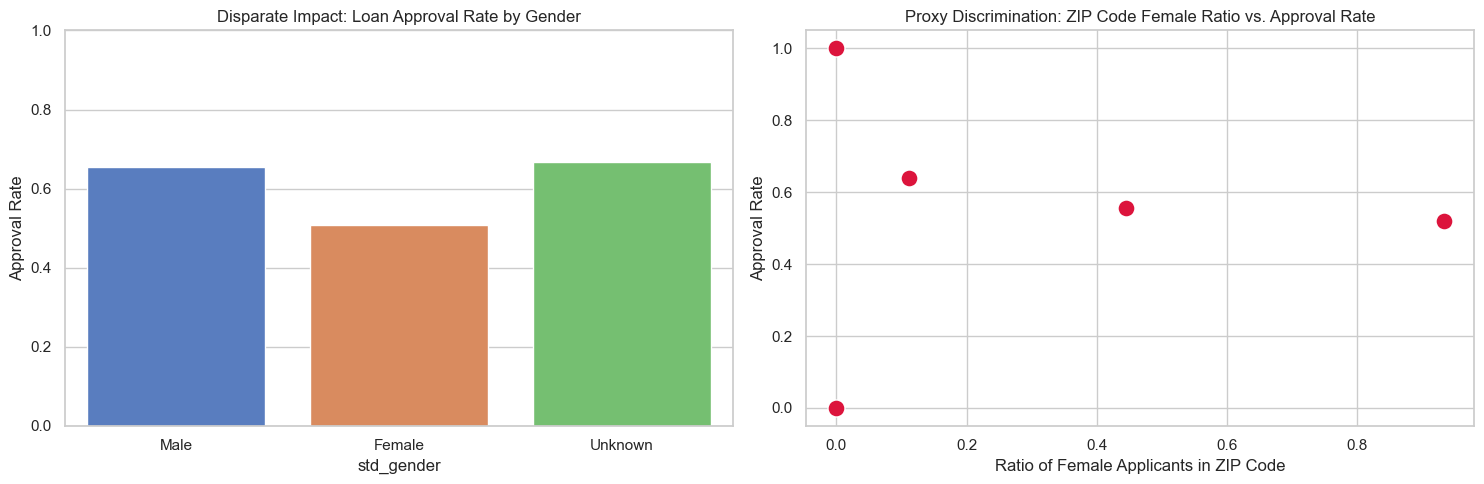


--- INTERACTION EFFECT: GENDER + AGE ---
Analyzing if the discrimination compounds when we look at young females specifically.


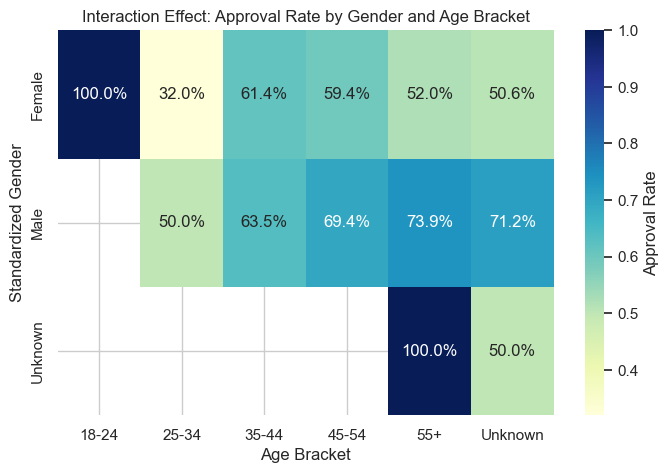

In [22]:
print("--- GENERATING FAIRNESS VISUALIZATIONS ---\n")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Gender Bias
sns.barplot(data=df_clean, x='std_gender', y='decision.loan_approved', errorbar=None, hue='std_gender', palette='muted', ax=axes[0], legend=False)
axes[0].set_title('Disparate Impact: Loan Approval Rate by Gender')
axes[0].set_ylabel('Approval Rate')
axes[0].set_ylim(0, 1)

# Plot 2: Proxy Discrimination
sns.scatterplot(data=zip_analysis, x='female_ratio', y='approval_rate', s=150, color='crimson', ax=axes[1])
axes[1].set_title('Proxy Discrimination: ZIP Code Female Ratio vs. Approval Rate')
axes[1].set_xlabel('Ratio of Female Applicants in ZIP Code')
axes[1].set_ylabel('Approval Rate')
plt.tight_layout()
plt.show()

# Plot 3: Interaction Effect (Gender + Age)
print("\n--- INTERACTION EFFECT: GENDER + AGE ---")
print("Analyzing if the discrimination compounds when we look at young females specifically.")
interaction_rates = df_clean.groupby(['std_gender', 'age_bracket'])['decision.loan_approved'].mean().unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(interaction_rates, annot=True, fmt=".1%", cmap="YlGnBu", cbar_kws={'label': 'Approval Rate'})
plt.title('Interaction Effect: Approval Rate by Gender and Age Bracket')
plt.ylabel('Standardized Gender')
plt.xlabel('Age Bracket')
plt.show()

## Part 4: Official Governance Mapping & Recommendations

Below is the formal mapping of our technical findings to actual legal requirements. This forms the basis of our policy recommendations.

### 1. GDPR Compliance Gaps & Fixes
* **Article 5(1)(a) - Lawfulness & Transparency:** The dataset has zero evidence of consent. NovaCred currently has no documented legal basis to process this data. Additionally, our fairness audit proves the outcomes aren't "fair," showing a Disparate Impact Ratio below the 0.80 threshold.
* **Article 5(1)(c) - Data Minimization:** We successfully remediated compliance gaps. We replaced exact birth dates with age brackets and truncated ZIP and IP addresses to limit unnecessary tracking.
* **Article 5(1)(f) - Integrity & Confidentiality:** We implemented a secure HMAC-SHA256 hash for the SSNs. This protects a permanent, sensitive identifier from plain-text exposure while still allowing our data engineering team to catch duplicate applications safely.
* **Article 17 - Right to Erasure:** Because we are missing processing timestamps, NovaCred currently has no automated way to know when to delete old data to comply with user deletion requests.

### 2. EU AI Act Status (High-Risk System)
Because NovaCred's AI assesses creditworthiness, it is explicitly classified as a **High-Risk AI System**. 
* **Article 10 - Data Quality:** Our audit script caught major errors. We must put input validation blocks on our data ingestion pipeline before training any models. 
* **Article 14 - Human Oversight:** Every single decision in this dataset looks completely automated. We need to implement a company policy where human reviewers must sign off on algorithmic loan rejections before the customer is notified.

### 3. Immediate Action Plan
1. **Bias Monitoring:** Establish a scheduled bias monitor triggering a manual review if the DI ratio drops below 0.80.
2. **Explainability:** Replace the generic `algorithm_risk_score` rejection label with a structured explanation of the top contributing risk factors.
3. **Data Quality Gates:** Implement rigid schema checks to prevent string incomes and impossible dates from entering the database.